In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit.circuit.library import EfficientSU2
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.primitives import StatevectorEstimator
from qiskit_algorithms.optimizers import COBYLA, QNSPSA
import time
import matplotlib

# Visual configuration for plots
plt.style.use('seaborn-v0_8-whitegrid')

Starting Comparative Barren Plateau Simulation (Scaling up to 20 qubits)...


C:\Users\admin\AppData\Local\Temp\ipykernel_2124\2449922693.py:24: DeprecationWarning: The class ``qiskit.circuit.library.n_local.efficient_su2.EfficientSU2`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.efficient_su2 instead.
  ansatz_A = EfficientSU2(num_qubits=n, reps=3, entanglement='full')
C:\Users\admin\AppData\Local\Temp\ipykernel_2124\2449922693.py:30: DeprecationWarning: The class ``qiskit.circuit.library.n_local.efficient_su2.EfficientSU2`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.efficient_su2 instead.
  ansatz_B = EfficientSU2(num_qubits=n, reps=reps_log, entanglement='linear')


Qubits: 2  | Reps_B: 1 | Var Worst: 0.13483934 | Var Mitigated: 0.0108 | Time: 0.98 s
Qubits: 4  | Reps_B: 2 | Var Worst: 0.03342821 | Var Mitigated: 0.0084 | Time: 1.77 s
Qubits: 6  | Reps_B: 3 | Var Worst: 0.00578563 | Var Mitigated: 0.0095 | Time: 3.14 s
Qubits: 8  | Reps_B: 3 | Var Worst: 0.00173179 | Var Mitigated: 0.0095 | Time: 4.56 s
Qubits: 10 | Reps_B: 3 | Var Worst: 0.00047589 | Var Mitigated: 0.0096 | Time: 8.07 s
Qubits: 12 | Reps_B: 4 | Var Worst: 0.00012742 | Var Mitigated: 0.0116 | Time: 13.94 s
Qubits: 14 | Reps_B: 4 | Var Worst: 0.00003434 | Var Mitigated: 0.0114 | Time: 29.29 s

Simulation finished in 61.75 seconds.


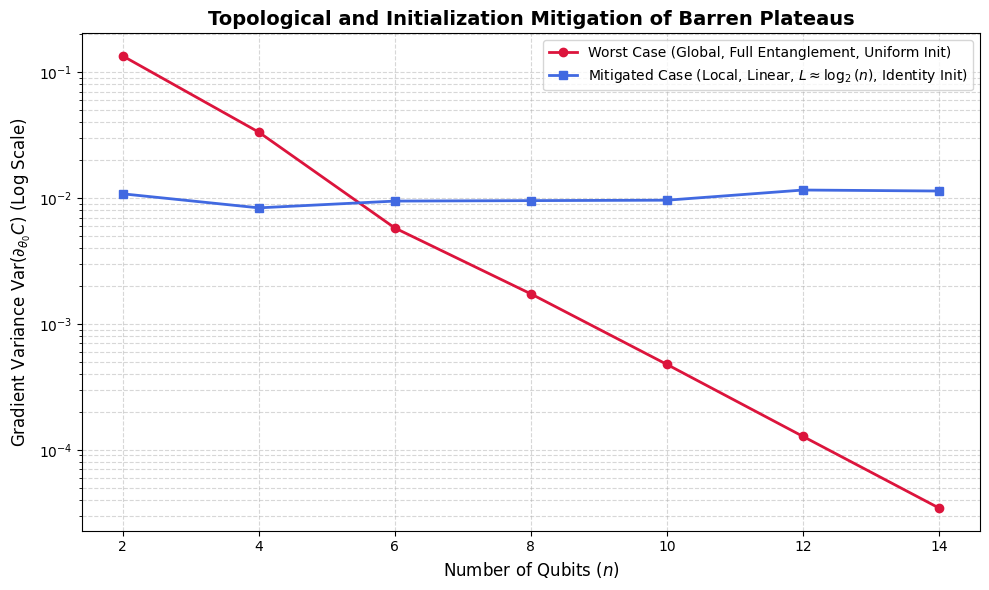

In [ ]:


# 1. Configuration
qubit_list = [2, 4, 6, 8, 10, 12, 14]
num_samples = 150
estimator = StatevectorEstimator()

variances_worst_case = []
variances_mitigated_case = []

print("Starting Comparative Barren Plateau Simulation (Scaling up to 20 qubits)...")
start_total = time.time()

for n in qubit_list:
    start_q = time.time()

    # --- ARCHITECTURE A: THE WORST CASE ---
    # Global Cost, Full Entanglement, Constant Depth
    ansatz_A = EfficientSU2(num_qubits=n, reps=3, entanglement='full')
    observable_A = SparsePauliOp.from_list([("Z" * n, 1)])

    # --- ARCHITECTURE B: THE MITIGATED CASE ---
    # Local Cost, Linear Entanglement, Logarithmic Depth O(log n)
    reps_log = max(1, int(np.round(np.log2(n))))
    ansatz_B = EfficientSU2(num_qubits=n, reps=reps_log, entanglement='linear')
    observable_B = SparsePauliOp.from_list([("I" * (n - 1) + "Z", 1)])

    grads_A = []
    grads_B = []

    for _ in range(num_samples):
        # Worst Case: Random uniform initialization mapping to the Haar measure
        params_A = np.random.uniform(-np.pi, np.pi, ansatz_A.num_parameters)

        # Mitigated Case: Identity Initialization
        # We sample from a narrow Gaussian centered at 0 to measure the local variance
        # representing the start of the optimization trajectory.
        params_B = np.random.normal(loc=0.0, scale=0.1, size=ansatz_B.num_parameters)

        # Parameter-shift rule (evaluating the partial derivative wrt the first parameter)
        p_plus_A, p_minus_A = params_A.copy(), params_A.copy()
        p_plus_A[0] += np.pi / 2
        p_minus_A[0] -= np.pi / 2

        p_plus_B, p_minus_B = params_B.copy(), params_B.copy()
        p_plus_B[0] += np.pi / 2
        p_minus_B[0] -= np.pi / 2

        # Primitive execution
        job_A = estimator.run([(ansatz_A, observable_A, [p_plus_A, p_minus_A])])
        job_B = estimator.run([(ansatz_B, observable_B, [p_plus_B, p_minus_B])])

        res_A = job_A.result()[0].data.evs
        res_B = job_B.result()[0].data.evs

        grads_A.append(0.5 * (res_A[0] - res_A[1]))
        grads_B.append(0.5 * (res_B[0] - res_B[1]))

    # Calculate and store the statistical variance
    var_A = np.var(grads_A)
    var_B = np.var(grads_B)

    variances_worst_case.append(var_A)
    variances_mitigated_case.append(var_B)

    print(f"Qubits: {n:<2} | Reps_B: {reps_log} | Var Worst: {var_A:.8f} | Var Mitigated: {var_B:.4f} | Time: {time.time() - start_q:.2f} s")

print(f"\nSimulation finished in {time.time() - start_total:.2f} seconds.")

# 2. Plotting the comparison
plt.figure(figsize=(10, 6))

# Worst Case Plot
plt.plot(qubit_list, variances_worst_case, 'o-', color='crimson', linewidth=2, label='Worst Case (Global, Full Entanglement, Uniform Init)')

# Mitigated Case Plot
plt.plot(qubit_list, variances_mitigated_case, 's-', color='royalblue', linewidth=2, label='Mitigated Case (Local, Linear, $L \\approx \\log_2(n)$, Identity Init)')

plt.yscale('log')
plt.title('Topological and Initialization Mitigation of Barren Plateaus', fontsize=14, fontweight='bold')
plt.xlabel('Number of Qubits ($n$)', fontsize=12)
plt.ylabel('Gradient Variance $\\text{Var}(\\partial_{\\theta_0} C)$ (Log Scale)', fontsize=12)
plt.xticks(qubit_list)
plt.legend(fontsize=10)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_2124\1893376514.py:89: DeprecationWarning: The class ``qiskit.circuit.library.n_local.efficient_su2.EfficientSU2`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.efficient_su2 instead.
  ansatz_A = EfficientSU2(num_qubits=n_qubits, reps=3, entanglement="full")
C:\Users\admin\AppData\Local\Temp\ipykernel_2124\1893376514.py:95: DeprecationWarning: The class ``qiskit.circuit.library.n_local.efficient_su2.EfficientSU2`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.efficient_su2 instead.
  ansatz_B = EfficientSU2(num_qubits=n_qubits, reps=reps_log, entanglement="linear")


Comparing both models at n=8 qubits
A (Worst): reps=3, entanglement=full, global observable
B (Mitigated): reps=3, entanglement=linear, local observable

--- Training A - Worst ---
[A - Worst] Iter 0  | Cost: 0.070201 | Grad Norm: 0.463510
[A - Worst] Iter 5  | Cost: -0.456211 | Grad Norm: 0.325393
[A - Worst] Iter 10 | Cost: -0.634195 | Grad Norm: 0.243573
[A - Worst] Iter 15 | Cost: -0.794827 | Grad Norm: 0.252826
[A - Worst] Iter 20 | Cost: -0.912819 | Grad Norm: 0.161260
[A - Worst] Iter 25 | Cost: -0.953915 | Grad Norm: 0.095292
[A - Worst] Iter 30 | Cost: -0.970859 | Grad Norm: 0.069644
[A - Worst] Iter 35 | Cost: -0.980801 | Grad Norm: 0.055620
[A - Worst] Iter 40 | Cost: -0.987194 | Grad Norm: 0.044510
[A - Worst] Iter 45 | Cost: -0.991243 | Grad Norm: 0.035652
[A - Worst] Iter 50 | Cost: -0.993426 | Grad Norm: 0.067699
[A - Worst] Iter 55 | Cost: -0.952505 | Grad Norm: 0.661585

--- Training B - Mitigated ---
[B - Mitigated] Iter 0  | Cost: 0.978329 | Grad Norm: 0.208443
[B - 

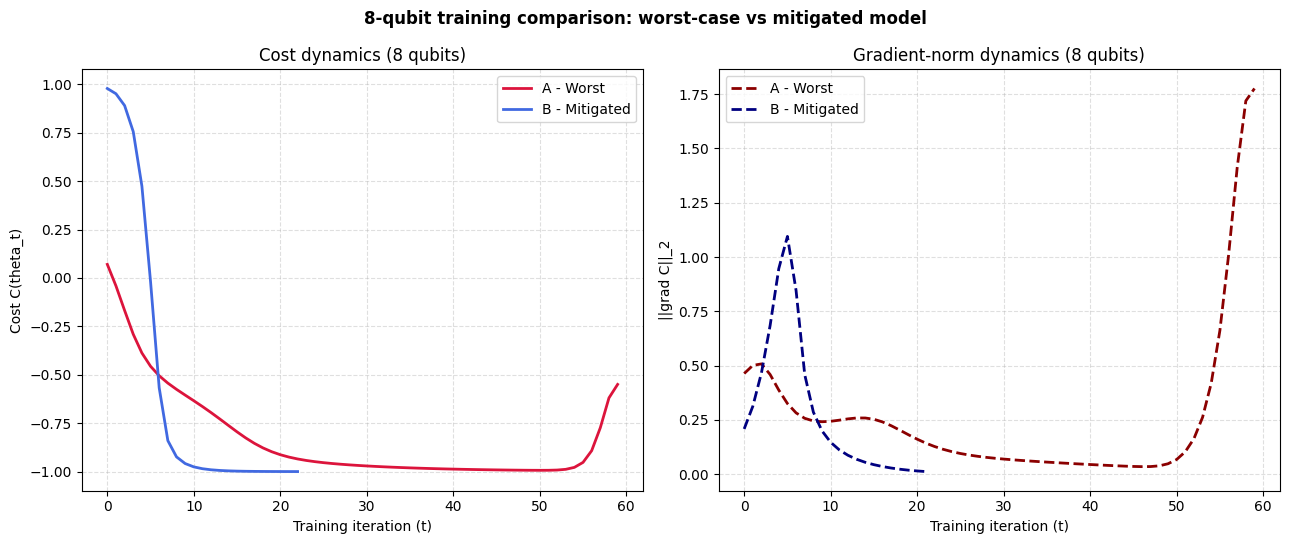

In [ ]:


def train_with_parameter_shift(
    ansatz,
    observable,
    init_params,
    estimator,
    learning_rate=0.5,
    max_iterations=60,
    tolerance=1e-4,
    log_every=5,
    tag="Model",
):
    """Train one circuit with exact parameter-shift gradients and return history."""
    theta_t = init_params.copy()
    num_params = ansatz.num_parameters

    history_cost = []
    history_grad_norm = []

    print(f"\n--- Training {tag} ---")
    for t in range(max_iterations):
        # Cost evaluation
        job_cost = estimator.run([(ansatz, observable, [theta_t])])
        current_cost = job_cost.result()[0].data.evs[0]
        history_cost.append(current_cost)

        # Early stopping on cost variation
        if t > 0:
            cost_diff = abs(history_cost[t - 1] - current_cost)
            if cost_diff < tolerance:
                print(f"[{tag}] Early stopping at iter {t}: |dC|={cost_diff:.6e} < {tolerance:.1e}")
                break

        # Full gradient via parameter-shift
        gradient_vector = np.zeros(num_params)
        pubs = []
        for i in range(num_params):
            p_plus = theta_t.copy()
            p_minus = theta_t.copy()
            p_plus[i] += np.pi / 2
            p_minus[i] -= np.pi / 2
            pubs.append((ansatz, observable, [p_plus, p_minus]))

        job_grad = estimator.run(pubs)
        results = job_grad.result()

        for i in range(num_params):
            gradient_vector[i] = 0.5 * (results[i].data.evs[0] - results[i].data.evs[1])

        grad_norm = np.linalg.norm(gradient_vector)
        history_grad_norm.append(grad_norm)

        # Gradient descent update
        theta_t = theta_t - learning_rate * gradient_vector

        if t % log_every == 0:
            print(f"[{tag}] Iter {t:<2} | Cost: {current_cost:.6f} | Grad Norm: {grad_norm:.6f}")

    return {
        "history_cost": history_cost,
        "history_grad_norm": history_grad_norm,
        "final_params": theta_t,
        "iterations": len(history_cost),
        "final_cost": history_cost[-1],
        "final_grad_norm": history_grad_norm[-1] if history_grad_norm else 0.0,
    }


# 1) Shared experiment setup (8 qubits)
n_qubits = 8
estimator = StatevectorEstimator()

learning_rate = 0.5
max_iterations = 60
tolerance = 1e-4

# Reproducible initialization
seed = 7
rng = np.random.default_rng(seed)

# 2) Model A: Worst-case architecture
ansatz_A = EfficientSU2(num_qubits=n_qubits, reps=3, entanglement="full")
observable_A = SparsePauliOp.from_list([("Z" * n_qubits, 1)])
params_A0 = rng.uniform(-np.pi, np.pi, size=ansatz_A.num_parameters)

# 3) Model B: Mitigated architecture
reps_log = int(np.round(np.log2(n_qubits)))
ansatz_B = EfficientSU2(num_qubits=n_qubits, reps=reps_log, entanglement="linear")
observable_B = SparsePauliOp.from_list([("I" * (n_qubits - 1) + "Z", 1)])
params_B0 = rng.normal(loc=0.0, scale=0.1, size=ansatz_B.num_parameters)

print(f"Comparing both models at n={n_qubits} qubits")
print(f"A (Worst): reps={3}, entanglement=full, global observable")
print(f"B (Mitigated): reps={reps_log}, entanglement=linear, local observable")

start = time.time()
result_A = train_with_parameter_shift(
    ansatz_A,
    observable_A,
    params_A0,
    estimator,
    learning_rate=learning_rate,
    max_iterations=max_iterations,
    tolerance=tolerance,
    tag="A - Worst",
)

result_B = train_with_parameter_shift(
    ansatz_B,
    observable_B,
    params_B0,
    estimator,
    learning_rate=learning_rate,
    max_iterations=max_iterations,
    tolerance=tolerance,
    tag="B - Mitigated",
)

print(f"\nTotal runtime: {time.time() - start:.2f} s")
print(
    f"A summary -> iters: {result_A['iterations']}, final cost: {result_A['final_cost']:.6f}, "
    f"final grad norm: {result_A['final_grad_norm']:.6f}"
)
print(
    f"B summary -> iters: {result_B['iterations']}, final cost: {result_B['final_cost']:.6f}, "
    f"final grad norm: {result_B['final_grad_norm']:.6f}"
)


# 4) Comparison plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))

# Cost comparison
ax1.plot(result_A["history_cost"], "-", linewidth=2, color="crimson", label="A - Worst")
ax1.plot(result_B["history_cost"], "-", linewidth=2, color="royalblue", label="B - Mitigated")
ax1.set_xlabel("Training iteration (t)")
ax1.set_ylabel("Cost C(theta_t)")
ax1.set_title("Cost dynamics (8 qubits)")
ax1.grid(True, linestyle="--", alpha=0.4)
ax1.legend()

# Gradient norm comparison
ax2.plot(result_A["history_grad_norm"], "--", linewidth=2, color="darkred", label="A - Worst")
ax2.plot(result_B["history_grad_norm"], "--", linewidth=2, color="navy", label="B - Mitigated")
ax2.set_xlabel("Training iteration (t)")
ax2.set_ylabel("||grad C||_2")
ax2.set_title("Gradient-norm dynamics (8 qubits)")
ax2.grid(True, linestyle="--", alpha=0.4)
ax2.legend()

plt.suptitle("8-qubit training comparison: worst-case vs mitigated model", fontweight="bold")
fig.tight_layout()
plt.show()